# Étude complète d’un matériau cristallin
Notebook structuré selon les consignes du projet.

Remplacer `MATERIAL_NAME` par le matériau attribué.

## 1. Téléchargement de la structure cristalline

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pymatgen as mg
import pymatviz as pv
# Exemple avec pymatgen (Materials Project)
from mp_api.client import MPRester

API_KEY = "PXBFSqNjWuCbMDn152B5RsMt61dfXOLI"
material_id = "mp-1378"  # Remplacer par l'ID réel

with MPRester(API_KEY) as mpr:
    structure = mpr.get_structure_by_material_id(material_id)

structure

Retrieving MaterialsDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

## 2. Réseau direct et réciproque

In [ ]:
import numpy as np

lattice = structure.lattice
a1, a2, a3 = lattice.matrix
reciprocal_lattice = lattice.reciprocal_lattice.matrix

print("Vecteurs réseau direct:")
print(a1, a2, a3)

print("Vecteurs réseau réciproque:")
print(reciprocal_lattice)

# #représentation des réseaux
# # reseau direct
# fig = plt.figure()
# ax = fig.add_subplot(111, projection='3d')

# # Origine
# origin = [0, 0, 0]

# # Tracé des vecteurs
# ax.quiver(*origin, *a1, length=1, normalize=False)
# ax.quiver(*origin, *a2, length=1, normalize=False)
# ax.quiver(*origin, *a3, length=1, normalize=False)

# # Labels
# ax.text(*a1, "a1")
# ax.text(*a2, "a2")
# ax.text(*a3, "a3")

# ax.set_xlabel("X")
# ax.set_ylabel("Y")
# ax.set_zlabel("Z")

# plt.show()

# # reseau reciproque
# fig = plt.figure()
# ax = fig.add_subplot(111, projection='3d')
# # Tracé des vecteurs
# ax.quiver(*origin, *reciprocal_lattice[0], length=1, normalize=False)
# ax.quiver(*origin, *reciprocal_lattice[1], length=1, normalize=False)
# ax.quiver(*origin, *reciprocal_lattice[2], length=1, normalize=False)

# # Labels
# ax.text(*reciprocal_lattice[0], "b1")
# ax.text(*reciprocal_lattice[1], "b2")
# ax.text(*reciprocal_lattice[2], "b3")

# ax.set_xlabel("X")
# ax.set_ylabel("Y")
# ax.set_zlabel("Z")

# plt.show()


Vecteurs réseau direct:
[3.20947838 0.         1.61193507] [1.42666349 3.56532885 1.16053063] [-0.0052797  -0.0235133   4.01163211]
Vecteurs réseau réciproque:
[[ 1.95870735 -0.78312019 -0.00201224]
 [-0.00518063  1.76101721  0.010315  ]
 [-0.78553983 -0.19477746  1.56406616]]


RuntimeError: Visualization requires the installation of VTK with Python bindings.

## 3. Type de maille, système cristallin, groupe ponctuel

In [5]:
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer

sga = SpacegroupAnalyzer(structure)

print("Système cristallin:", sga.get_crystal_system())
print("Type de maille:", sga.get_lattice_type())
print("Groupe ponctuel:", sga.get_point_group_symbol())

Système cristallin: orthorhombic
Type de maille: orthorhombic
Groupe ponctuel: mmm


## 4. Application de trois éléments de symétrie

In [6]:
# Exemple d'opérations de symétrie
sym_ops = sga.get_symmetry_operations()

for i in range(3):
    print(sym_ops[i])

Rot:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
tau
[0. 0. 0.]
Rot:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
tau
[0. 0. 0.]
Rot:
[[-1.  0.  0.]
 [ 0. -1.  0.]
 [ 0.  0. -1.]]
tau
[0. 0. 0.]


## 5. Visualisation de la zone de Brillouin

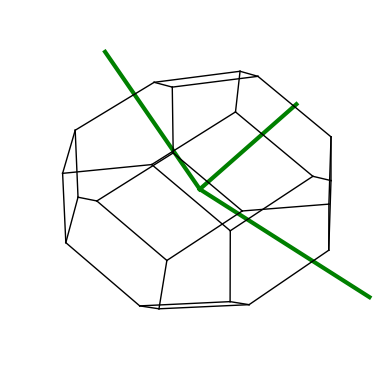

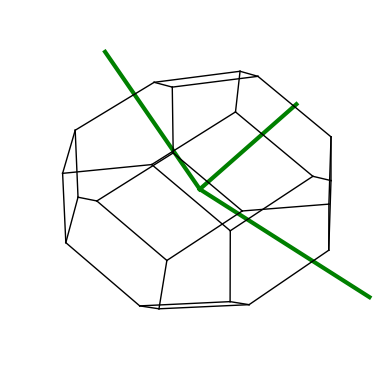

In [7]:
from pymatgen.electronic_structure.plotter import plot_brillouin_zone

plot_brillouin_zone(lattice.reciprocal_lattice)

## 6. Diffractogramme (Cu Kα, λ=1.54060 Å)

In [8]:
from pymatgen.analysis.diffraction.xrd import XRDCalculator

wavelength = 1.54060
xrd = XRDCalculator(wavelength=wavelength)
pattern = xrd.get_pattern(structure)

pattern

## 7. Structure de bandes électroniques

In [9]:
# Télécharger la structure de bandes
band_structure = mpr.get_bandstructure_by_material_id(material_id)

band_structure

Retrieving ElectronicStructureDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

## 8. Analyse de la structure de bandes

In [10]:
band_gap = band_structure.get_band_gap()
print("Bande interdite:", band_gap)

Bande interdite: {'direct': False, 'transition': 'W-\\Gamma', 'energy': 3.2727}


## 9. Masse effective (approximation parabolique)

In [ ]:
# Exemple conceptuel
# m* = ħ² / (d²E/dk²)

import scipy.constants as const

hbar = const.hbar

# Calcul numérique à compléter

## 10. Structure de bandes de phonons

In [9]:
phonon_bs = mpr.get_phonon_bandstructure_by_material_id(material_id)
phonon_bs

MPRestError: No object found: s3://materialsproject-parsed/ph-bandstructures/dfpt/mp-1378.json.gz

## 11. Vitesse du son (branches acoustiques)

In [ ]:
# v = dω/dk proche de Gamma
# Calcul numérique à compléter

## 12. Densité d'états de phonons

In [12]:
phonon_dos = mpr.get_phonon_dos_by_material_id(material_id)
phonon_dos

MPRestError: Failed to retrieve data from OpenData with status code 404:
Not Found

## 13. Modèles de Debye et d'Einstein

In [ ]:
# Ajustement moindres carrés pour ΘD et ΘE
# Implémentation à compléter

## 14. Courbes de chaleur spécifique

In [ ]:


# Tracer les trois courbes ici

plt.show()